In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.inspection import PartialDependenceDisplay
import pickle
import xgboost as xgb
import os
from sklearn.metrics import f1_score, roc_auc_score


In [82]:
#Load the game data
game_data = pd.read_csv("/home/iolson26/Math stuff/Games_Spreadsheets/Compiled DATA REAL.csv")
game_data.head()

,Date,Year,Home_team,Away_Team,Home_winner?,Away_Winner?,Ratio A/T,APG,BKPG,RPG DEF,...,RPG,REB MAR,OPP PPG,PPG,SCR MAR,STPG,Pct (W/L),3FG% OPP,3FG%,TO MAR
0,11-13-2015,2015,Michigan State,Florida Atlantic,True,False,0.77,8.8,0.9,5.43,...,9.0,17.7,-9.9,13.5,23.4,-0.8,58.7,-4.5,9.6,-1.6
1,11-13-2015,2015,Old Dominion,Niagara,True,False,0.71,2.5,0.7,1.14,...,2.3,5.7,-10.4,3.9,14.4,0.6,43.9,-4.2,1.9,4.6
2,11-13-2015,2015,Purdue,N.C. A&T,True,False,0.68,7.0,2.3,4.91,...,5.4,11.8,-10.8,10.1,21.0,-0.9,43.0,-2.5,5.3,-1.5
3,11-13-2015,2015,VCU,Prairie View A&M,True,False,0.67,5.7,1.1,4.29,...,5.2,8.4,-3.2,16.9,20.1,0.9,46.8,3.1,8.0,2.5
4,11-13-2015,2015,Virginia,Morgan State,True,False,0.65,3.6,1.0,0.41,...,-3.0,7.5,-11.6,3.6,15.2,-0.7,49.4,3.2,10.2,-0.3


In [83]:
#Format game data
game_data = game_data.drop(columns=["Date", "Year", "Home_team", "Away_Team", "Away_Winner?"
                                    , "Pct (W/L)"
                                    , "SCR MAR"
                                    #,"APG", "RPG DEF", "TO MAR", "FT%", "RPG OFF", "3FG%", "OPP RPG"
                                    ])
game_data.head()

,Home_winner?,Ratio A/T,APG,BKPG,RPG DEF,FG%,OPP FG%,FT%,RPG OFF,PFPG,OPP RPG,RPG,REB MAR,OPP PPG,PPG,STPG,3FG% OPP,3FG%,TO MAR
0,True,0.77,8.8,0.9,5.43,7.9,-7.6,-0.2,3.65,0.1,-8.7,9.0,17.7,-9.9,13.5,-0.8,-4.5,9.6,-1.6
1,True,0.71,2.5,0.7,1.14,3.9,-2.8,-1.3,1.18,-1.5,-3.5,2.3,5.7,-10.4,3.9,0.6,-4.2,1.9,4.6
2,True,0.68,7.0,2.3,4.91,6.4,-5.3,3.3,0.47,-5.1,-6.4,5.4,11.8,-10.8,10.1,-0.9,-2.5,5.3,-1.5
3,True,0.67,5.7,1.1,4.29,7.1,-1.6,0.6,0.97,-2.7,-3.0,5.2,8.4,-3.2,16.9,0.9,3.1,8.0,2.5
4,True,0.65,3.6,1.0,0.41,9.5,-3.6,6.7,-3.43,-2.4,-10.6,-3.0,7.5,-11.6,3.6,-0.7,3.2,10.2,-0.3


In [84]:
#Split game data into train, test, and validation sets
x, y = game_data.loc[:, (game_data.columns != "Home_winner?")], game_data["Home_winner?"]
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=.2, random_state=42)
xtrain, xval, ytrain, yval = train_test_split(xtrain,ytrain, test_size=.25, random_state=42)

In [85]:
#Black magic that encodes the game data so it can be read by the model
label_encoder = LabelEncoder()
ytrain = label_encoder.fit_transform(ytrain)
yval   = label_encoder.transform(yval)
ytest  = label_encoder.transform(ytest)

In [86]:
#This black magic scales it to be read by the model
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xval = scaler.transform(xval)
xtest = scaler.transform(xtest)

In [250]:
#THis is old tuning that i dont want to get rid of but prolly will never use again
xgb_classifier = xgb.XGBClassifier(random_state=42,
                                   n_estimators=300,
                                   max_depth=3,
                                   learning_rate=.07,
                                   subsample=.8,
                                   colsample_bytree=.85,
                                   gamma=.2,
                                   reg_alpha=0,
                                   reg_lambda=1.2,
                                   min_child_weight=3,
                                   scale_pos_weight=.9,
                                   n_jobs= -1
                                   )


xgb_classifier.fit(xtrain,ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.07, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [271]:
xgb_classifier = xgb.XGBClassifier(
    colsample_bytree =0.95, 
    eval_metric= 'logloss', 
    gamma= 0.2, 
    learning_rate= 0.07, 
    max_depth= 4, 
    max_leaves= None, 
    min_child_weight= 3, 
    monotone_constraints= None, 
    multi_strategy= None, 
    n_estimators= 500, 
    n_jobs= -1, 
    num_parallel_tree= None, 
    random_state= 42, 
    reg_alpha= 0.1, 
    reg_lambda= 1.2, 
    sampling_method= None, 
    scale_pos_weight= 1, 
    subsample= 0.9, 
    tree_method= 'hist', 
    validate_parameters= None, 
    verbosity= 1
                                   )


xgb_classifier.fit(xtrain,ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.95, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.07, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [272]:
ypred = xgb_classifier.predict(xval)

test_accuracy = accuracy_score(yval, ypred)

print("Test Accuracy: ", test_accuracy)
print("Classification Report: ", classification_report(yval, ypred))
print("Confusion Matrix: ", confusion_matrix(yval, ypred))



Test Accuracy:  0.7351702562868487
Classification Report:                precision    recall  f1-score   support

           0       0.66      0.51      0.58      2944
           1       0.76      0.86      0.81      5367

    accuracy                           0.74      8311
   macro avg       0.71      0.69      0.69      8311
weighted avg       0.73      0.74      0.73      8311

Confusion Matrix:  [[1514 1430]
 [ 771 4596]]


In [148]:

# Since your positives are majority (~26k vs 14k), test values < 1
scale_pos_weights = [0.7,.8 ,.9, 1.0]
results = []

for spw in scale_pos_weights:
    model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.1,
        subsample=1.0,
        colsample_bytree=1.0,  # all features since only 18
        scale_pos_weight=spw,
        use_label_encoder=False,
        eval_metric='auc',
        random_state=42
    )
    
    model.fit(xtrain, ytrain)
    
    # Predictions
    y_pred = model.predict(xval)
    y_pred_proba = model.predict_proba(xval)[:,1]
    
    # Metrics
    f1 = f1_score(yval, y_pred)
    auc = roc_auc_score(yval, y_pred_proba)
    
    results.append((spw, f1, auc))
    print(f"scale_pos_weight={spw}: F1={f1:.4f}, AUC={auc:.4f}")
    
    # Find best F1
best_f1 = max(results, key=lambda x: x[1])
print(f"Best F1: scale_pos_weight={best_f1[0]}, F1={best_f1[1]:.4f}, AUC={best_f1[2]:.4f}")

# Find best AUC
best_auc = max(results, key=lambda x: x[2])
print(f"Best AUC: scale_pos_weight={best_auc[0]},
      F1={best_auc[1]:.4f}, AUC={best_auc[2]:.4f}")

/home/iolson26/.local/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:33:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


scale_pos_weight=0.7: F1=0.7912, AUC=0.7855


/home/iolson26/.local/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:33:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


scale_pos_weight=0.8: F1=0.7964, AUC=0.7846


/home/iolson26/.local/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:33:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


scale_pos_weight=0.9: F1=0.7976, AUC=0.7833


/home/iolson26/.local/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:33:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


scale_pos_weight=1.0: F1=0.8025, AUC=0.7841
Best F1: scale_pos_weight=1.0, F1=0.8025, AUC=0.7841
Best AUC: scale_pos_weight=0.7, F1=0.7912, AUC=0.7855


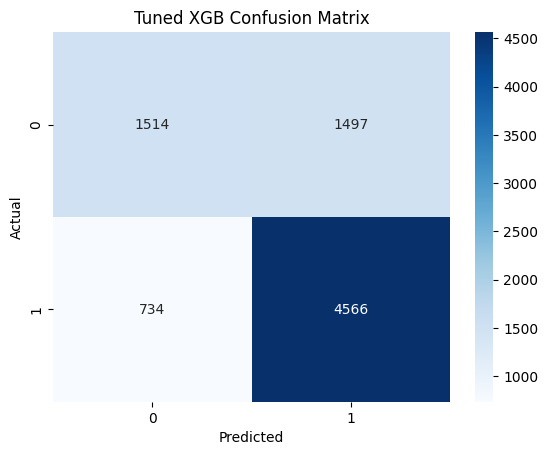

<Figure size 640x480 with 0 Axes>

In [283]:
sns.heatmap(
    confusion_matrix(ytest, xgb_classifier.predict(xtest)),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned XGB Confusion Matrix")
plt.show()
plt.savefig("Tuned_XGB_Confusion_Matrix.png", dpi=300)

In [ ]:
param_grid = {
    "n_estimators": [300],       # Number of boosting rounds
    "max_depth": [3, 5, 7, 9],                   # Maximum depth of a tree
    "learning_rate": [0.01, 0.05, 0.1, 0.2, .3],    # Step size shrinkage
    "subsample": [0.6, .7, 0.8, .9],               # Fraction of data used per tree
    "colsample_bytree": [.4, .5, 0.6, 0.8, 1.0],        # Fraction of features per tree
    "gamma": [0, 0.1, 0.3, 0.5],                # Minimum loss reduction to make a split
    "reg_alpha": [0, 0.01, 0.1, 1],             # L1 regularization
    "reg_lambda": [1, 1.5, 2],                   # L2 regularization
    "min_child_weight": [1, 3, 5],              # Minimum sum of instance weight needed in a child
    "scale_pos_weight": [.56],  # if your classes are imbalanced
}

xgb_classifier = xgb.XGBClassifier(random_state=42)

#Hyper Params 

rand_search = RandomizedSearchCV(xgb_classifier, param_grid, cv=5, n_iter=10, scoring='accuracy', n_jobs=-1, verbose=2, random_state=42)
rand_search.fit(xtrain, ytrain)
best_xgb = rand_search.best_estimator_
'''
Best Parameters:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)
'''

print("Best Parameters: ", rand_search.best_estimator_)
print('Scale_Pos_Weight: ',best_xgb.scale_pos_weight)
print("Best Accuracy: ", rand_search.best_score_)

In [193]:
tune_this_shit = pd.read_csv("/home/iolson26/Math stuff/Games_Spreadsheets/22-23 stats mm.csv")
tune_this_shit = tune_this_shit.drop(columns=["GameID", "Date", "Year", "Home_team", "Away_Team", "Away_Winner?","Home_Seed",	"Away_Seed"
                              , "Pct (W/L)"
                              , "SCR MAR"
                              ])
x_tune, y_tune = tune_this_shit.loc[:, (tune_this_shit.columns != "Home_winner?")], tune_this_shit["Home_winner?"]
x_tune = tune_this_shit[x.columns]
x_tune = scaler.transform(x_tune)



In [246]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import ParameterSampler
from tqdm import tqdm

# -------------------------------------------------
# SMART PARAMETER GRID (NO CLASS WEIGHTING)
# -------------------------------------------------
param_grid = {
    "max_depth": [3, 4],
    "learning_rate": [.01,0.03, 0.05, 0.07, 0.1],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.7, 0.85, .9, .95],
    "min_child_weight": [1, 2, 3],
    "gamma": [0, 0.1, 0.2],
    "reg_alpha": [0, 0.05, 0.1],
    "reg_lambda": [0.8, 1.0, 1.2],
    "scale_pos_weight": [.9, .95, 1]  
}

n_iter = 100  # good balance of speed + quality

random_params = list(ParameterSampler(
    param_grid,
    n_iter=n_iter,
    random_state=42
))

best_model = None
best_score = -np.inf
results = []

# -------------------------------------------------
# RANDOM SEARCH LOOP
# -------------------------------------------------
for params in tqdm(random_params, desc="Random Search"):

    model = xgb.XGBClassifier(
        random_state=42,
        tree_method="hist",
        n_jobs=-1,
        eval_metric="logloss",
        n_estimators=500,              # high cap
        early_stopping_rounds=30,      # XGB 3.x style
        verbosity=0,
        **params
    )

    model.fit(
        xtrain,
        ytrain,
        eval_set=[(x_tune, y_tune)],
        verbose=False
    )

    y_proba = model.predict_proba(x_tune)[:, 1]
    y_pred = (y_proba > 0.5).astype(int)

    f1 = f1_score(y_tune, y_pred)
    auc = roc_auc_score(y_tune, y_proba)
    ll = log_loss(y_tune, y_proba)

    results.append((params, f1, auc, ll))

    if f1 > best_score:
        best_score = f1
        best_model = model

# -------------------------------------------------
# RESULTS
# -------------------------------------------------
results_df = pd.DataFrame(results, columns=["params", "F1", "AUC", "LogLoss"])
results_df = results_df.sort_values("F1", ascending=False)

print("\nBEST MODEL RESULTS")
print(results_df.head(5))

print("\nBest Parameters:")
print(best_model.get_params())

Random Search:   0%|          | 0/100 [00:00<?, ?it/s]

Random Search: 100%|██████████| 100/100 [21:37<00:00, 12.97s/it]


BEST MODEL RESULTS
                                               params        F1       AUC  \
96  {'subsample': 0.9, 'scale_pos_weight': 1, 'reg...  0.821429  0.602484   
5   {'subsample': 0.9, 'scale_pos_weight': 0.9, 'r...  0.814815  0.621118   
86  {'subsample': 0.8, 'scale_pos_weight': 0.9, 'r...  0.814815  0.627329   
87  {'subsample': 0.8, 'scale_pos_weight': 0.9, 'r...  0.814815  0.629400   
53  {'subsample': 0.9, 'scale_pos_weight': 1, 'reg...  0.814159  0.641822   

     LogLoss  
96  0.610135  
5   0.603142  
86  0.598333  
87  0.599845  
53  0.596687  

Best Parameters:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.95, 'device': None, 'early_stopping_rounds': 30, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0.2, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 

In [262]:
ypred = model.predict(xtest)

test_accuracy = accuracy_score(ytest, ypred)

print("Test Accuracy: ", test_accuracy)
print("Classification Report: ", classification_report(ytest, ypred))
print("Confusion Matrix: ", confusion_matrix(ytest, ypred))

Test Accuracy:  0.7172422091204428
Classification Report:                precision    recall  f1-score   support

           0       0.73      0.35      0.47      3011
           1       0.71      0.93      0.81      5300

    accuracy                           0.72      8311
   macro avg       0.72      0.64      0.64      8311
weighted avg       0.72      0.72      0.69      8311

Confusion Matrix:  [[1055 1956]
 [ 394 4906]]


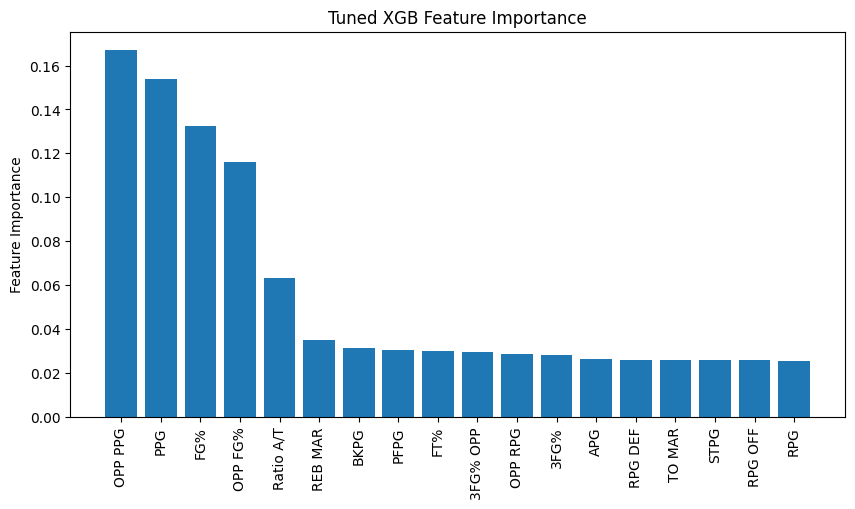

<Figure size 640x480 with 0 Axes>

In [275]:
feature_importance = xgb_classifier.feature_importances_
feature_names = x.columns

sort_indices = np.argsort(feature_importance)[::-1]
plt.figure(figsize=(10,5))
plt.bar(range(len(feature_importance)), feature_importance[sort_indices], align="center")
plt.xticks(range(len(feature_importance)), np.array(feature_names)[sort_indices], rotation=90)
plt.ylabel("Feature Importance")
plt.title("Tuned XGB Feature Importance")
plt.show()
plt.savefig("Tuned_XGB_Feature_importance.png", dpi=300)

In [273]:
val_23 = pd.read_csv("/home/iolson26/Math stuff/Games_Spreadsheets/22-23 stats mm.csv")
val_23 = val_23.drop(columns=["GameID", "Date", "Year", "Home_team", "Away_Team", "Away_Winner?","Home_Seed",	"Away_Seed"
                              , "Pct (W/L)"
                              , "SCR MAR"
                              ])
val_23 = val_23[x.columns]

val_23_scaled = scaler.transform(val_23)
predictions = xgb_classifier.predict(val_23_scaled)
print(predictions)

probabilities = xgb_classifier.predict_proba(val_23_scaled)
print(probabilities)

[1 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1]
[[0.19597918 0.8040208 ]
 [0.42730355 0.57269645]
 [0.6628466  0.33715338]
 [0.45562375 0.54437625]
 [0.2954932  0.7045068 ]
 [0.29019594 0.70980406]
 [0.3557647  0.6442353 ]
 [0.12967849 0.8703215 ]
 [0.25811762 0.7418824 ]
 [0.5815962  0.4184038 ]
 [0.24376541 0.7562346 ]
 [0.35207736 0.64792264]
 [0.4522099  0.5477901 ]
 [0.708463   0.291537  ]
 [0.31659222 0.6834078 ]
 [0.40417278 0.5958272 ]
 [0.15016216 0.84983784]
 [0.04105884 0.95894116]
 [0.04581624 0.95418376]
 [0.2229752  0.7770248 ]
 [0.5990519  0.4009481 ]
 [0.2211079  0.7788921 ]
 [0.29702163 0.7029784 ]
 [0.2183941  0.7816059 ]
 [0.24183482 0.7581652 ]
 [0.4506781  0.5493219 ]
 [0.2338677  0.7661323 ]
 [0.27031034 0.72968966]
 [0.1263746  0.8736254 ]
 [0.42787254 0.57212746]
 [0.18634838 0.8136516 ]
 [0.52592367 0.47407633]
 [0.35620052 0.6437995 ]
 [0.3777057  0.6222943 ]
 [0.18031049 

In [274]:
games_for_output = pd.read_csv('/home/iolson26/Math stuff/Games_Spreadsheets/22-23 stats mm.csv')
results = pd.DataFrame(columns=["Home", "Away", "P_Home_Lose", "P_Home_Win","Home_win_bool"])
results["Home"] = games_for_output['Home_team']
results["Away"] = games_for_output['Away_Team']
results["P_Home_Lose"] = probabilities[:, 0]  # probability of home team losing
results["P_Home_Win"]  = probabilities[:, 1]  # probability of home team winning
results['Home_win_bool'] = predictions


results.to_csv("march_madness_predictions.csv", index=False)
results.head()

,Home,Away,P_Home_Lose,P_Home_Win,Home_win_bool
0,A&M-Corpus Christi,Southeast Mo. State,0.195979,0.804021,1
1,Mississippi State,Pittsburgh,0.427304,0.572696,1
2,Texas Southern,FDU,0.662847,0.337153,0
3,Arizona State,Nevada,0.455624,0.544376,1
4,Maryland,West Virginia,0.295493,0.704507,1


In [276]:
march_madness_games = pd.read_csv('/home/iolson26/Math stuff/Games_Spreadsheets/23-24MM Games&Stats.csv')
march_madness_games = march_madness_games.drop(columns=["GameID", "Date", "Year", "Home_team", "Away_Team", "Away_Winner?","Home_Seed",	"Away_Seed"
                                                        , "Home Win %",	"Away Win %"
                                                        , "Pct (W/L)", "SCR MAR"
                                                        #,"APG", "RPG DEF", "TO MAR", "FT%", "RPG OFF", "3FG%", "OPP RPG"
                                                        ])
march_madness_games.head()

,Home_winner?,Ratio A/T,APG,BKPG,RPG DEF,FG%,OPP FG%,FT%,RPG OFF,PFPG,OPP RPG,RPG,REB MAR,OPP PPG,PPG,STPG,3FG% OPP,3FG%,TO MAR
0,False,-0.39,1.1,0.7,-0.32,5.9,2.8,3.9,-0.26,3.7,-2.6,-0.6,2.1,12.3,11.6,0.1,4.1,5.2,-4.6
1,False,0.04,-3.2,1.9,-1.12,-5.4,-3.0,-11.7,1.06,-3.6,1.6,-0.1,-1.7,-8.8,-12.8,0.6,-2.7,2.2,2.2
2,False,0.39,3.3,-0.7,1.26,2.6,3.2,2.7,-2.83,2.5,1.9,-1.6,-3.4,5.1,7.5,0.8,-0.5,2.8,2.5
3,False,-0.13,-3.4,0.3,-1.63,-4.1,0.2,-4.3,1.26,1.8,-0.3,-0.4,-0.1,-3.7,-3.5,-0.1,-0.7,-4.9,2.3
4,False,-0.58,-2.2,-0.8,1.46,-0.6,0.4,-3.4,2.26,0.2,-1.3,3.8,5.1,3.2,1.7,0.9,-3.4,-3.4,-3.1


In [277]:
march_madness_games = march_madness_games[feature_names]

march_madness_games_scaled = scaler.transform(march_madness_games)

In [278]:
predictions = xgb_classifier.predict(march_madness_games_scaled)
print(predictions)

probabilities = xgb_classifier.predict_proba(march_madness_games_scaled)
print(probabilities)

[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1]
[[0.5098157  0.49018428]
 [0.4354744  0.5645256 ]
 [0.31551528 0.6844847 ]
 [0.32494473 0.67505527]
 [0.48005956 0.51994044]
 [0.2231195  0.7768805 ]
 [0.12599099 0.874009  ]
 [0.03095585 0.96904415]
 [0.09810418 0.9018958 ]
 [0.33879858 0.6612014 ]
 [0.2758357  0.7241643 ]
 [0.377959   0.622041  ]
 [0.47836518 0.5216348 ]
 [0.22982073 0.7701793 ]
 [0.14568454 0.85431546]
 [0.43665862 0.5633414 ]
 [0.08562481 0.9143752 ]
 [0.27383834 0.72616166]
 [0.25389105 0.74610895]
 [0.49909174 0.50090826]
 [0.21976858 0.7802314 ]
 [0.2669658  0.7330342 ]
 [0.27284855 0.72715145]
 [0.2910959  0.7089041 ]
 [0.32896924 0.67103076]
 [0.02445298 0.975547  ]
 [0.08145434 0.91854566]
 [0.3031646  0.6968354 ]
 [0.26257223 0.7374278 ]
 [0.25564545 0.74435455]
 [0.02109748 0.9789025 ]
 [0.27833396 0.72166604]
 [0.05979937 0.9402006 ]
 [0.9117018  0.08829822]
 [0.26175052 

In [279]:
games_for_output = pd.read_csv('/home/iolson26/Math stuff/Games_Spreadsheets/23-24MM Games&Stats.csv')
results = pd.DataFrame(columns=["Home", "Away", "P_Home_Lose", "P_Home_Win","Home_win_bool"])
results["Home"] = games_for_output['Home_team']
results["Away"] = games_for_output['Away_Team']
results["P_Home_Lose"] = probabilities[:, 0]  # probability of home team losing
results["P_Home_Win"]  = probabilities[:, 1]  # probability of home team winning
results['Home_win_bool'] = predictions

results.to_csv("march_madness_predictions.csv", index=False)
results.head()

,Home,Away,P_Home_Lose,P_Home_Win,Home_win_bool
0,Howard,Wagner,0.509816,0.490184,0
1,Virginia,Colorado State,0.435474,0.564526,1
2,Montana State,Grambling,0.315515,0.684485,1
3,Boise State,Colorado,0.324945,0.675055,1
4,Mississippi State,Michigan State,0.480060,0.519940,1


/home/iolson26/.local/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


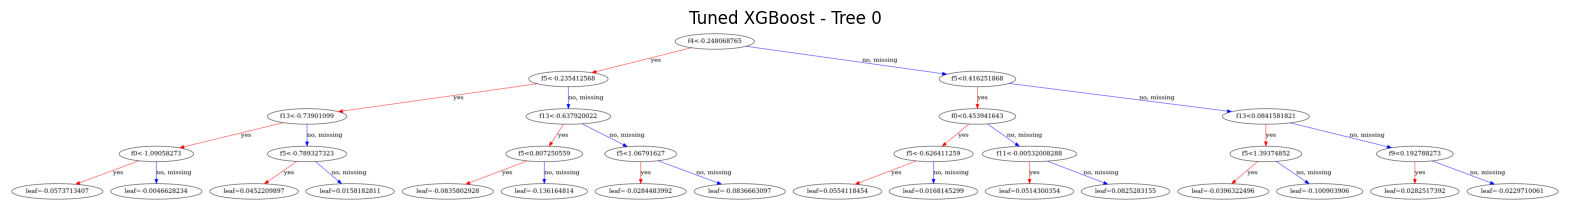

In [280]:
fig, ax = plt.subplots(figsize=(20, 10))
xgb.plot_tree(
    xgb_classifier,
    num_trees=0,
    feature_names=x.columns,
    ax=ax
)
plt.title("Tuned XGBoost - Tree 0")

output_path = os.path.join(os.getcwd(), "Tuned_xgb_tree_0.png")
fig.savefig(output_path, dpi=500, bbox_inches="tight")

plt.show()

/home/iolson26/.local/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/home/iolson26/.local/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


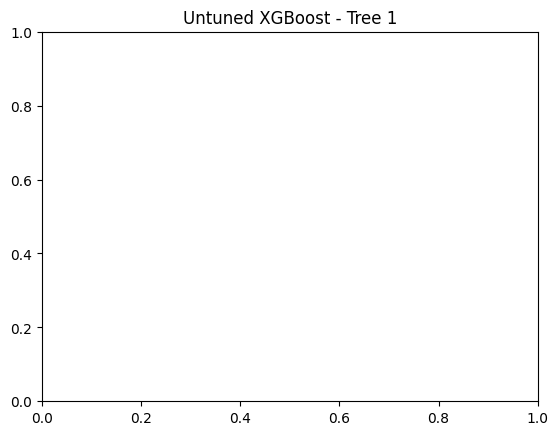

In [281]:
for n in range(2):
    xgb.plot_tree(
    xgb_classifier,
    num_trees=n,
    feature_names=x.columns,
    ax=ax
    )
    plt.title("Untuned XGBoost - Tree "+str(n))

    output_path = os.path.join(os.getcwd(), "Untuned_xgb_tree_"+str(n)+".png")
    fig.savefig(output_path, dpi=300, bbox_inches="tight")